# Probability & Statistics: III

*Davide Gerosa (Milano-Bicocca)*

##### Reading:

- [Ivezic textbook](https://press.princeton.edu/books/hardcover/9780691198309/statistics-data-mining-and-machine-learning-in-astronomy) Chapter 3. 


This course is based on previous work by many people. See [here]((https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/README.md) for credits.



---

## Central Limit Theorem <a class="anchor" id="one"></a>

One of the reasons that a Gaussian (or Normal) Distribution is so common is because of the **Central Limit Theorem**:

> For an arbitrary distribution, $h(x)$, with a well-defined mean, $\mu$, and standard deviation, $\sigma$ (i.e. tails should fall off faster than $1/x^2$) the mean of $N$ values \{$x_i$\} drawn from the distribution will follow a Gaussian Distribution with $\mathcal{N}(\mu,\sigma/\sqrt{N})$. 

(A Cauchy distribution is one example where this fails.)

This theorem is the foudation for the performing repeat measurements in order to improve the accuracy of one's experiment. This is truly amazing! No matter what distribution you start off with (provided it has a well defined mean and standard deviation) or the measurement process itself, repeated batches of $N$ draws will follow a Gaussian centered around the mean.  

Let's wrap our heads around what this means with some examples. 

We'll first consider $h(x) = \mathcal{N}(\mu=0.5,\sigma=1/\sqrt{12})$. According to the Central Limit Theorem, taking the mean of many batches of $N$ random samples should result in a normal distribution with $\mathcal{N}(\mu=0.5,\sigma=1/\sqrt{12}/\sqrt{N})$.

In [12]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform
from astroML import stats as astroMLstats
from tqdm.notebook import tqdm
plt.rcParams['figure.figsize'] = [6, 6]


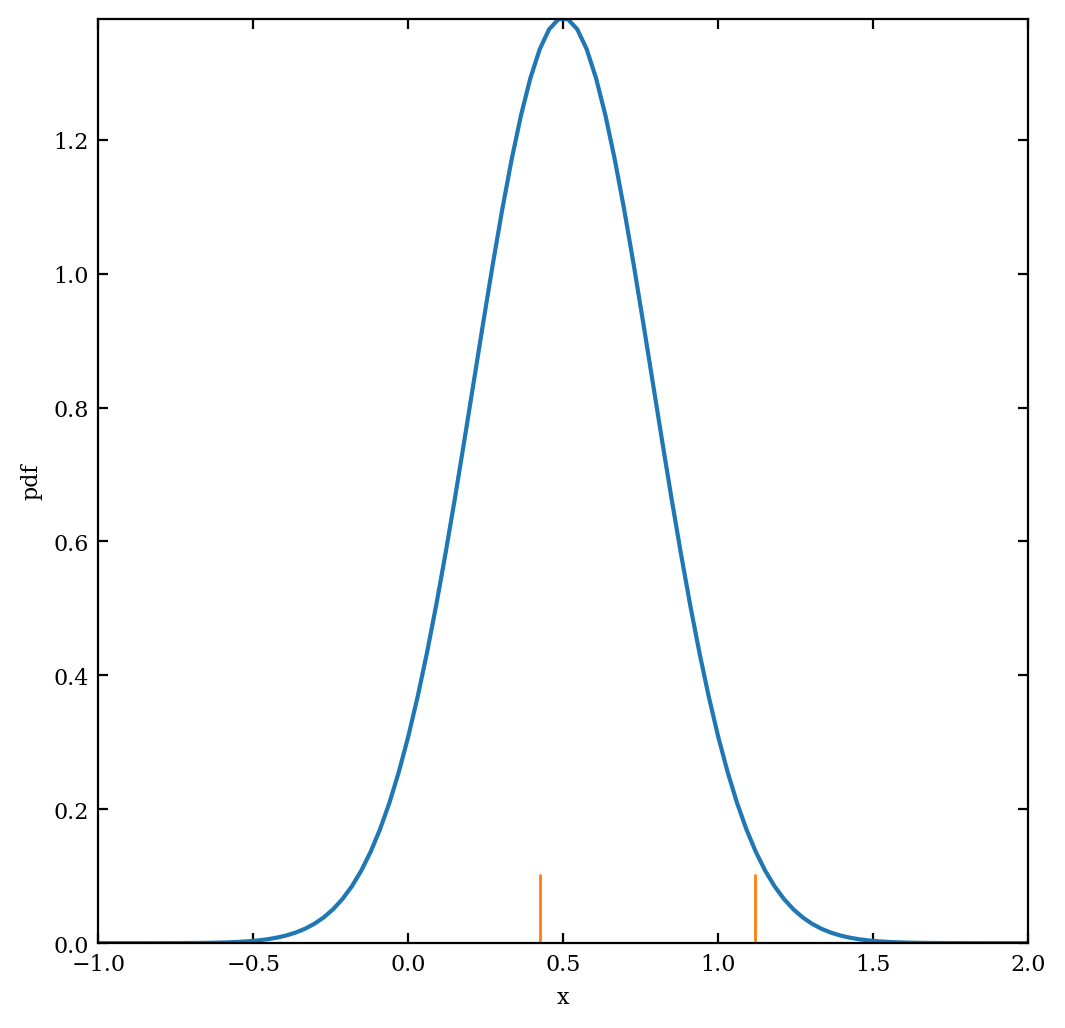

In [13]:
N = 2 # Number of draws
mu = 0.5 # Location
sigma_h = 1.0 / np.sqrt(12) # scale of h(x)

xgrid = np.linspace(-1,2,100)  
distG = scipy.stats.norm(loc=mu, scale=sigma_h)
plt.plot(xgrid, distG.pdf(xgrid))

x = np.random.normal(mu, sigma_h,2) # Two random draws
plt.plot(x, 0*x, '|', markersize=50)
plt.xlabel('x')
plt.ylabel('pdf');

Now let's average those two draws and plot the result (in the same panel). Do it as a histogram for 100,000 batches of 2 samples each. Use a stepfilled histogram that is normalized with 50% transparency and 100 bins.

  0%|          | 0/10000 [00:00<?, ?it/s]

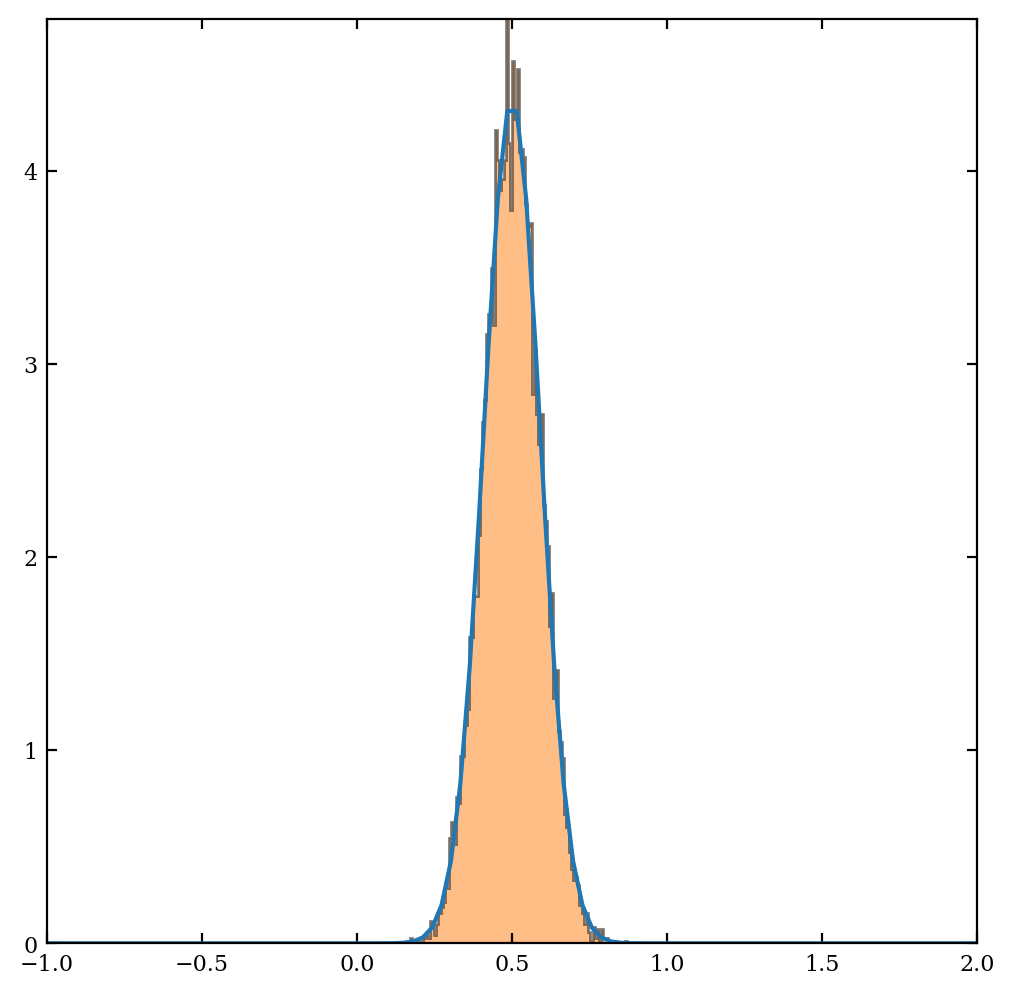

In [14]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm

N = 10 # Number of draws
mu = 0.5 # Location
sigma_h = 1.0 / np.sqrt(12) # scale of h(x)
sigma_cl = sigma_h / np.sqrt(N) # scale of mean error distribution

xgrid = np.linspace(-1,2,100)  

# plot the distribution of means according to central limit theorem
distG = scipy.stats.norm(mu, sigma_cl) # Complete
plt.plot(xgrid, distG.pdf(xgrid)) # Complete

# Add a histogram that is the mean of 100,000 batches of N draws
yy = []
for i in tqdm(np.arange(10000)):
    xx = np.random.normal(loc=mu, scale=sigma_h, size=N) # N random draws
    yy.append(np.average(xx)) # Append average of those random draws to the end of the array

plt.hist(yy, bins=100, histtype='stepfilled', alpha=0.5, density=True);

Well that's great and all, but didn't I say this worked for arbitrary generating distributions $h(x)$ so long as their mean and standard deviations were well defined? Let's check this out for a uniform distribution with $\mu=0.5$ and width$ =1$, such that the standard deviation is $\sigma=1/\sqrt{12}$ (see previous lecture).

  0%|          | 0/10000 [00:00<?, ?it/s]

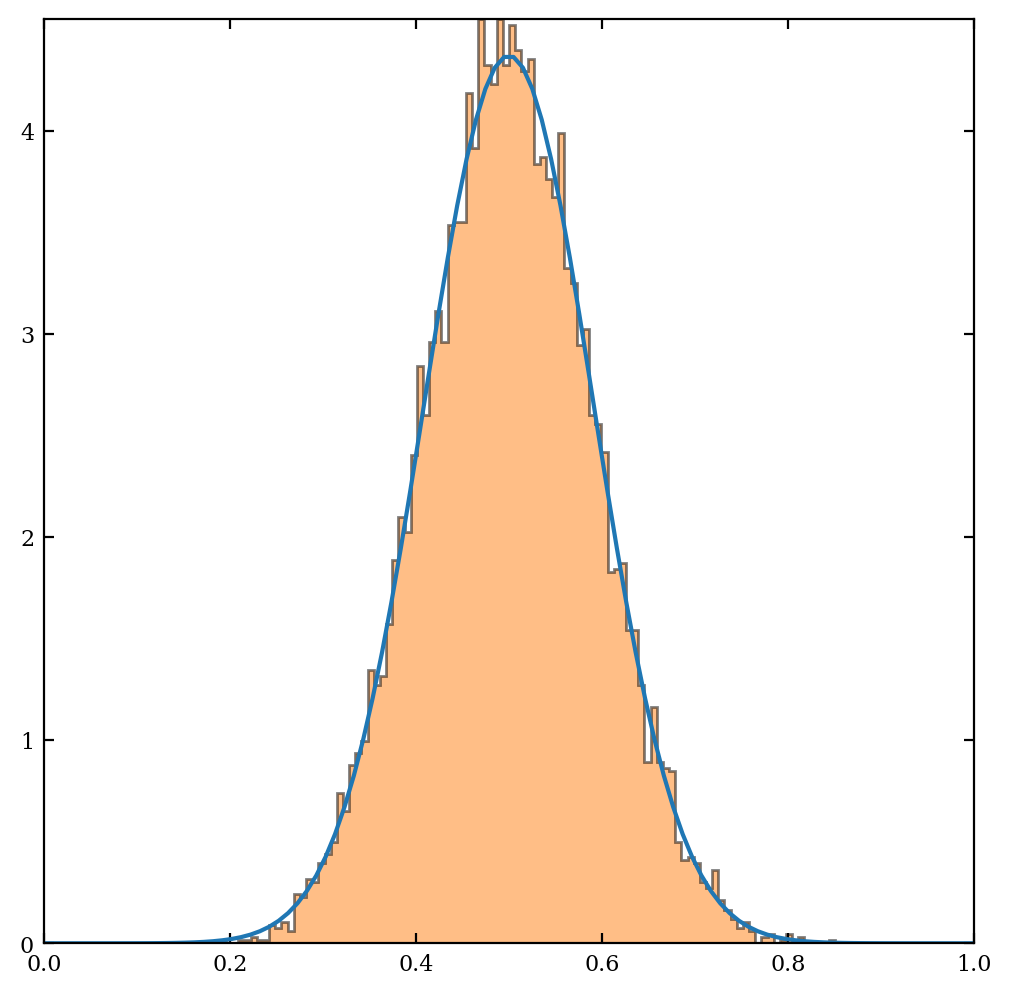

In [15]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm

N = 10 # Number of draws

xmin=0
xmax=1
mu = 0.5 # Location
sigma_h = 1.0 / np.sqrt(12) # scale of h(x)
sigma_cl = sigma_h / np.sqrt(N) # scale of mean error distribution
xgrid = np.linspace(0,1,100)  

# plot the distribution of means according to central limit theorem
distG = scipy.stats.norm(mu, sigma_cl) # Complete
plt.plot(xgrid, distG.pdf(xgrid)) # Complete

# Add a histogram that is the mean of 100,000 batches of N draws
yy = []
for i in tqdm(np.arange(10000)):
    xx = np.random.uniform(0,1,N) # N random draws
    yy.append(np.average(xx)) # Append average of those random draws to the end of the array

plt.hist(yy, bins=100, histtype='stepfilled', alpha=0.5, density=True);


Now that's impressive! Now instead of averaging 2 draws, average 3.  Then do it for 10.  Then for 100.  Each time for 100,000 samples.


For 100 you will note that your draws are clearly sampling the full range, but the means of those draws are in a *much* more restrictred range. Moreover they are very closely following a Normal Distribution. 

This is truly mind blowing, and a wonderful example of the power and generalizability of statistics in tackling the measured properties of arbitrary distributions. Even if you've never heard of or understood the Central Limit Theorem, you have been implicitly using it your entire career so far. 


### An example from my own research in gravitational waves

*"Testing general relativity with gravitational-wave catalogs: the insidious nature of waveform systematics"* Moore, Finch, Buscicchio, Gerosa. [arXiv:2103.16486](https://arxiv.org/abs/2103.16486)

When analyzing gravitational-wave data we have to impose a model of what our signal looks like (see time series part at the end of the class). But this model won't be perfect, i.e. our analysis suffers from systematics.

One of the things GW detections are good for is testing General Relativity. Now what happens when you have many events? They add up, such that statistical errors decreases but the systematics don't. But how do systematics add together? In principle this is a very complicated problem because the systematics are, by definition, unknown (if I knew that and effect exist I would put it in the model!). How do many unknown pieces add together? The shape of the pieces doesn't matter as long as there are many of them: it's going to be Gaussian!

See Sec 4 in that paper (above Eq 35) for a neat application of the Central Limit Theorem.


## Bivariate and Multivariate pdfs <a class="anchor" id="two"></a>

A few words about two-dimensional pds. Let's cosider $h(x,y)$ where $$\int_{-\infty}^{\infty}dx\int_{-\infty}^{\infty}h(x,y)dy = 1.$$  $h(x,y)$ is telling us the probability that $x$ is between $x$ and $dx$ and *also* that $y$ is between $y$ and $dy$.

Then we have the following definitions:

$$\mu_x = \int_{-\infty}^{\infty}\int_{-\infty}^{\infty}x h(x,y) dx dy$$

$$\mu_y = \int_{-\infty}^{\infty}\int_{-\infty}^{\infty}y h(x,y) dx dy$$

$$\sigma^2_x = \int_{-\infty}^{\infty}\int_{-\infty}^{\infty}(x-\mu_x)^2 h(x,y) dx dy$$

$$\sigma^2_y = \int_{-\infty}^{\infty}\int_{-\infty}^{\infty}(y-\mu_y)^2 h(x,y) dx dy$$


$$\sigma_{xy} = Cov(x,y) = \int_{-\infty}^{\infty}\int_{-\infty}^{\infty}(x-\mu_x) (y-\mu_y) h(x,y) dx dy$$

If $x$ and $y$ are uncorrelated, then we can treat the system as two independent 1-D distributions.  This means that choosing a range on one variable has no effect on the distribution of the other.

We can write a 2-D Gaussian pdf as
$$p(x,y|\mu_x,\mu_y,\sigma_x,\sigma_y,\sigma_{xy}) = \frac{1}{2\pi \sigma_x \sigma_y \sqrt{1-\rho^2}} \exp\left(\frac{-z^2}{2(1-\rho^2)}\right),$$

where $$z^2 = \frac{(x-\mu_x)^2}{\sigma_x^2} + \frac{(y-\mu_y)^2}{\sigma_y^2} - 2\rho\frac{(x-\mu_x)(y-\mu_y)}{\sigma_x\sigma_y},$$

with $$\rho = \frac{\sigma_{xy}}{\sigma_x\sigma_y}$$
as the **(dimensionless) correlation coefficient**.

If $x$ and $y$ are perfectly correlated then $\rho=\pm1$ and if they are uncorrelated, then $\rho=0$.

**The pdf is now not a histogram, but rather a series of contours in the $x-y$ plane.**   

These are centered at $(x=\mu_x, y=\mu_y)$ and are tilted at angle $\alpha$, which is given by
$$\tan(2 \alpha) = 2\rho\frac{\sigma_x\sigma_y}{\sigma_x^2-\sigma_y^2} = 2\frac{\sigma_{xy}}{\sigma_x^2-\sigma_y^2}.$$

For example (Ivezic, Figure 3.22):
![Ivezic, Figure 3.22](http://www.astroml.org/_images/fig_bivariate_gaussian_1.png)

We can define new coordinate axes that are aligned with the minimum and maximum widths of the distribution. (Or in different terminology, the semi-minor and semi-major axes of the ellipse). These are called the **principal axes** and are given by

$$P_1 = (x-\mu_x)\cos\alpha + (y-\mu_y)\sin\alpha,$$

and

$$P_2 = -(x-\mu_x)\sin\alpha + (y-\mu_y)\cos\alpha.$$

The widths in this (rotated) coordinate system are

$$\sigma^2_{1,2} = \frac{\sigma_x^2+\sigma_y^2}{2}\pm\sqrt{\left(\frac{\sigma_x^2-\sigma_y^2}{2}\right)^2 + \sigma^2_{xy}}.$$

Note that **the correlation vanishes in this coordinate system (by definition)** and the bivariate Gaussian is just a product of two univariate Gaussians.  

This concept will be crucial for understanding ***Principal Component Analysis*** (see later on in this course), where PCA extends this idea to even more dimensions.

In the univariate case we used $\overline{x}$ and $s$ to *estimate* $\mu$ and $\sigma$.  In the bivariate case we estimate 5 parameters: $(\overline{x},\overline{y},s_x,s_y,s_{xy})$.  

As with the univariate case, it is important to realize that **outliers can bias these estimates and that it may be more appropriate to use the median rather than the mean as a more robust estimator for $\mu_x$ and $\mu_y$**.  

Similarly we want robust estimators for the other parameters of the fit.  We won't go into that in detail right now, but see Ivezic, Figure 3.23 for an example:

![Ivezic, Figure 3.23](http://www.astroml.org/_images/fig_robust_pca_1.png)

The non-robust estimates (***dashed lines***) give biased sigma ellipses due to the outliers. The robust estimates (***solid lines***) do much better.

We can generalize the way we describe **Gaussian distributions in multiple dimensions**, $M$, through the elegance of linear algebra. Instead of writing everything in terms of separate coordinates, we can bundle everything together in an $M$-dimensional coordinate vector $\vec{x}$, mean vector $\vec{\mu}$, and covariance matrix $\mathbf{C} = E([\vec{x}-\vec{\mu}][\vec{x}-\vec{\mu}]^T)$.

$$p(\vec{x}|\vec{\mu},\mathbf{C}) = \frac{1}{\sqrt{\mathrm{det}(2\pi\mathbf{C})}} \exp\left[-\frac{1}{2}(\vec{x}-\vec{\mu})^T \mathbf{C}^{-1} (\vec{x}-\vec{\mu}) \right] $$

where 

$$ C_{kj} = \int_{-\infty}^\infty (x^k-\mu^k)(x^j-\mu^j)p(\vec{x}|\vec{\mu},\mathbf{C})\,d^M x $$

and 

$$ (\vec{x}-\vec{\mu})^T \mathbf{C}^{-1} (\vec{x}-\vec{\mu}) = \sum_{k=1}^M \sum_{j=1}^M [\mathbf{C}^{-1}]_{kj}(x^k-\mu^k)(x^j-\mu^j) $$

### Gaussian confidence levels in 2 dimensions

This discussion is inspired by Dan Foreman-Mackey's discussion in the context of the [corner](https://corner.readthedocs.io/en/latest/) software package: https://corner.readthedocs.io/en/latest/pages/sigmas.html 

In two dimensions, a Gaussian density can be described by

$$ \mathrm{pdf}(r) = \frac{1}{2\pi s^2}\exp\left[-\frac{1}{2}\left(\frac{r}{s}\right)^2\right] $$

with the cdf (using polar coordinates and implicitly integrating out the angle)

$$ \mathrm{cdf}(x) = 1 - \exp(-(x/s)^2/2) $$

This means that within "1-sigma", the Gaussian contains 1-exp(-0.5) $\sim 0.393$ or $39.3\%$ of the volume. Therefore in `corner`, the relevant 1-sigma levels for a 2D histogram of samples is 39% not 68%. 

If you are using `corner` and want the usual 68% of the "sample mass" definition of sigma, use the `levels` keyword argument when you call `corner.corner`.

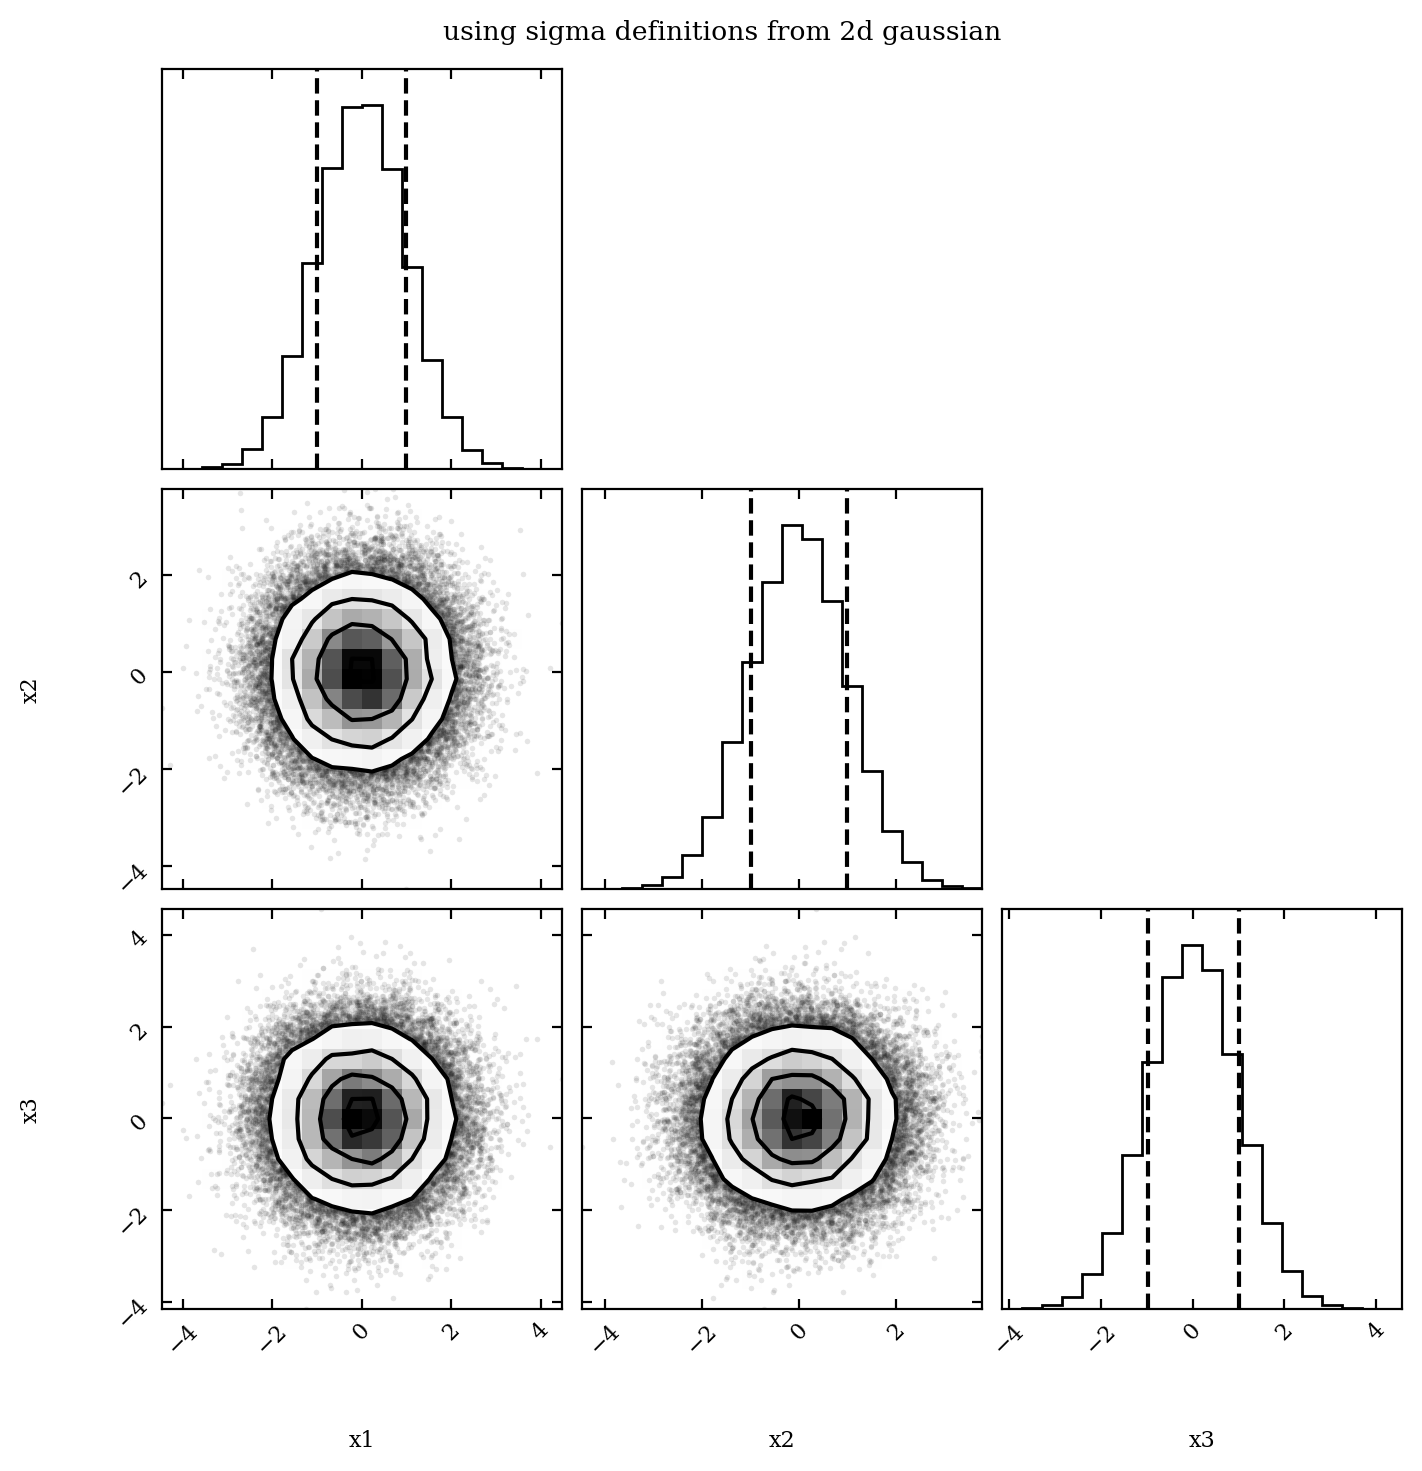

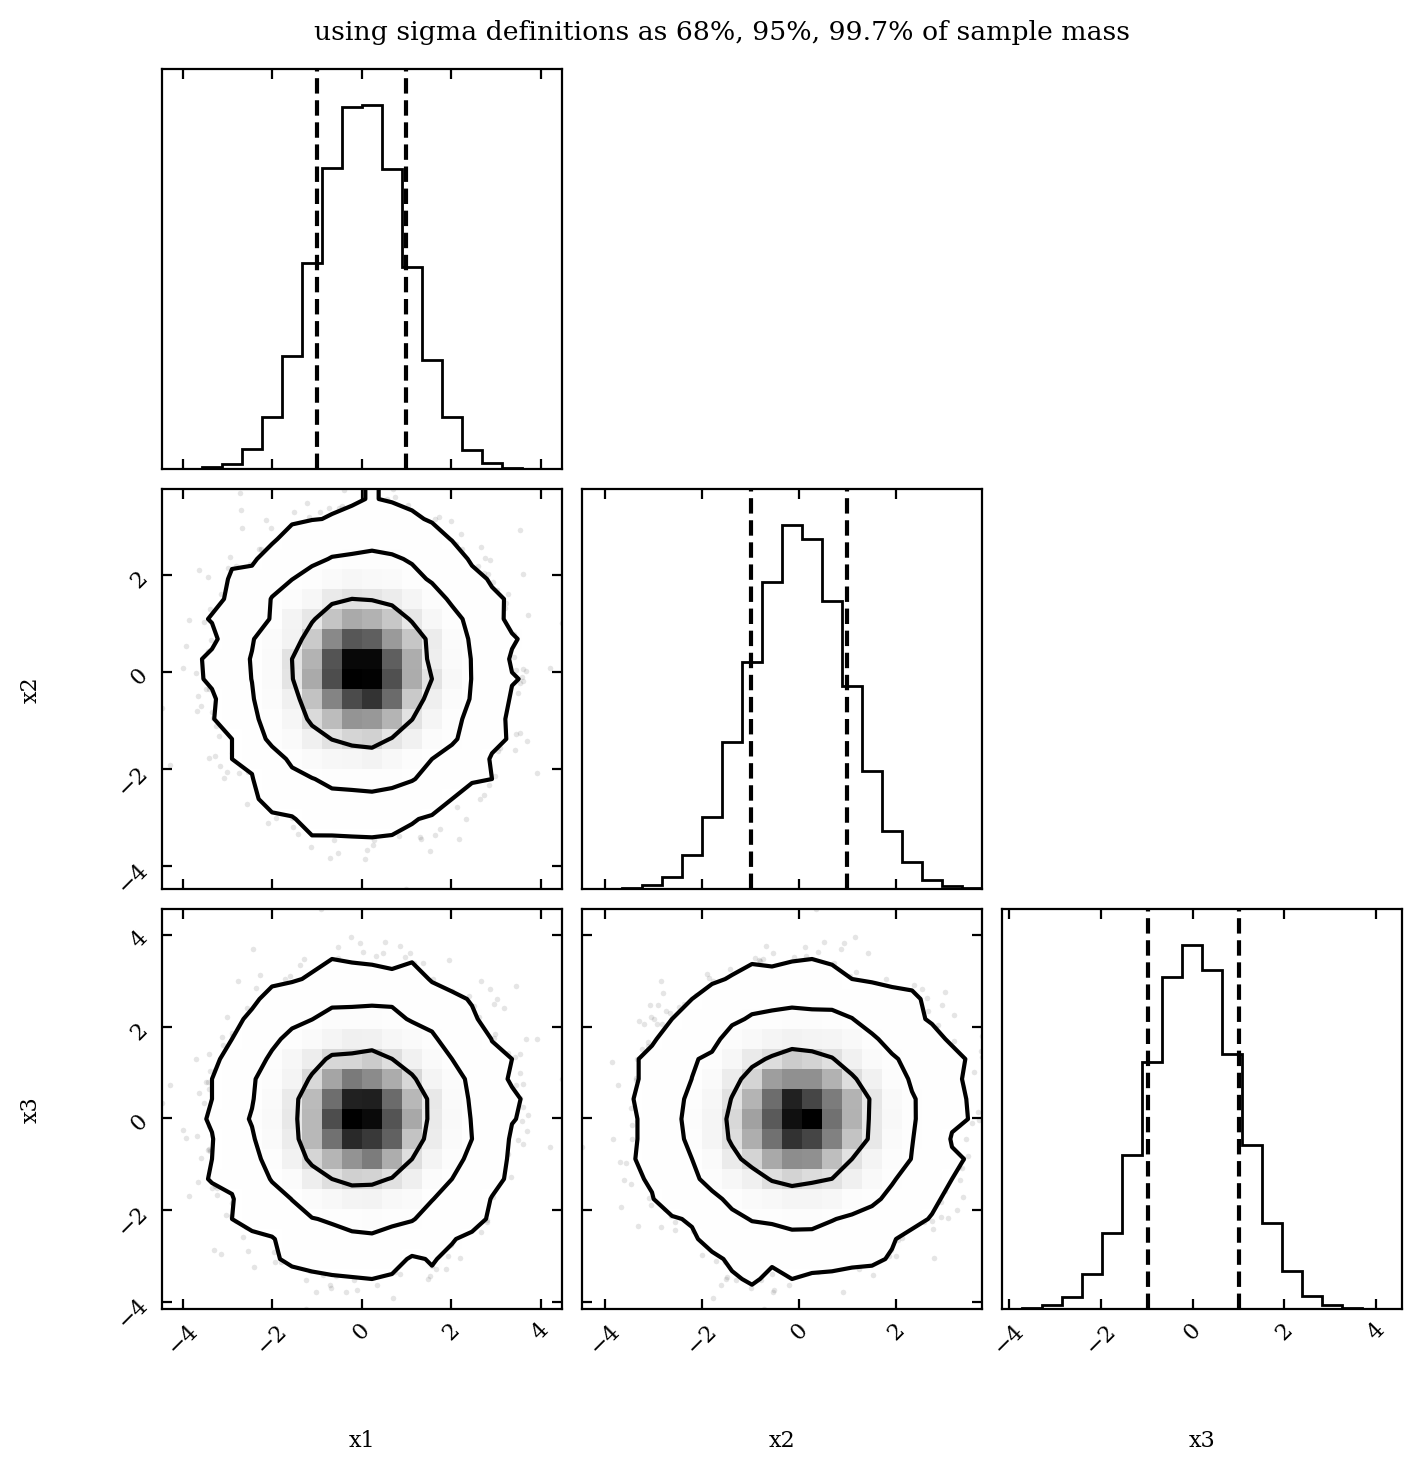

In [16]:
import corner

# Generate some fake data from a Gaussian
np.random.seed(42)
x = np.random.randn(50000, 3)

# formally correct sigma definition
fig = corner.corner(x, quantiles=(0.16, 0.84), labels=['x1','x2','x3'])
fig.suptitle("using sigma definitions from 2d gaussian");

# standard sample mass definition
fig = corner.corner(x, quantiles=(0.16, 0.84), levels=(0.68,0.95,0.997), labels=['x1','x2','x3'])
fig.suptitle("using sigma definitions as 68%, 95%, 99.7% of sample mass");

## Correlation coefficients <a class="anchor" id="three"></a>

We'd like to be able to quantify how well two samples of data are correlated with one another 

BTW: always remember that **correlation does not imply causation**. 

![](https://miro.medium.com/v2/resize:fit:1200/1*8j7U89RK1SgopIGET0mSFA.png)


For a somewhat funny (but sadly true) example:
- https://www.nature.com/articles/20094
- https://www.nature.com/articles/35004661
- https://qz.com/316826/mathematicians-have-finally-figured-out-how-to-tell-correlation-from-causation

### Pearson's coefficient

Given two length-$N$ samples of data $\{x_i\}$ and $\{y_i\}$, Pearson's correlation coefficient is defined as

$$ r = \frac{\sum_{i=1}^N (x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum_{i=1}^N (x_i-\bar{x})^2}\sqrt{\sum_{i=1}^N (y_i-\bar{y})^2}} $$

where $-1\leq r\leq 1$, and $r=0$ for uncorrelated variables.

If the pairs $(x_i,y_i)$ are drawn from uncorrelated univariate Gaussian distributions, then the distribution of $r$ follows a Student's $t$ distribution with $k=N-2$ degrees of freedom and $t = r\sqrt{(N-2)/(1-r^2)}$.

With this known "null hypothesis" distribution, a measured $r$ can be interpreted in terms of the significance with which we can reject the variables being correlated, e.g., if $N=10$ then the probability that a value of $r\geq 0.72$ arises just by chance noise fluctuations is $1\%$. 

There are two big problems with Pearson's coefficient though:
- It does not incorporate measurement uncertainties on the data.
- It is highly susceptible to outliers.

### Spearman's coefficient  (R the median of the data)

Similar definition to Pearson's, with sample values replaced by their cumulative ranks. As we've seen, cumulative statistics based on rank are more robust estimators than ones that use the actual sample values. The samples in each dataset are ranked from $1,\ldots,N$ in ascending order, with the largest value given the rank $N$. 

$$ r_S = \frac{\sum_{i=1}^N (R^x_i-\bar{R^x})(R^y_i-\bar{R^y})}{\sqrt{\sum_{i=1}^N (R^x_i-\bar{R^x})^2}\sqrt{\sum_{i=1}^N (R^y_i-\bar{R^y})^2}}. $$

The distribution of $r_S$ is the same as for Pearson's, except in the definition of the test statsitic $t$, $r$ is replaced by $r_S$.

### Kendall's coefficient

Kendall's coefficient uses the sample ranks, but does not take rank differences like in Spearman's coefficient. Instead, we compare the relative number of *concordant* and *discordant* pairs. 

**Concordant pairs** are where the differences in values between a pair of samples $j$ and $k$ have the same sign in $x$ and $y$, i.e., $(x_j-x_k)(y_j-y_k)>0$.

**Discordant pairs** are where the differences in values between a pair of samples $j$ and $k$ have the different signs in $x$ and $y$, i.e., $(x_j-x_k)(y_j-y_k)<0$.

*For perfectly correlated data, all $N(N-1)/2$ sample pairs will be concordant. For perfectly anti-correlated data, all pairs will be discordant.* 

Kendall's $\tau$ is then computed as

$$ \tau = 2\frac{N_c-N_d}{N(N-1)}.$$

In the following example that reproduces *Ivezic Fig. 3.24*, samples of $x$ and $y$ from a bivariate normal distribution with/without outlier contamination are assessed for correlation using each of the above. It is clear that Pearson's suffers considerably from outliers, while the rank-based coefficients are more resilient. 

@pickle_results: using precomputed results from 'fig_correlations_dump.pkl'


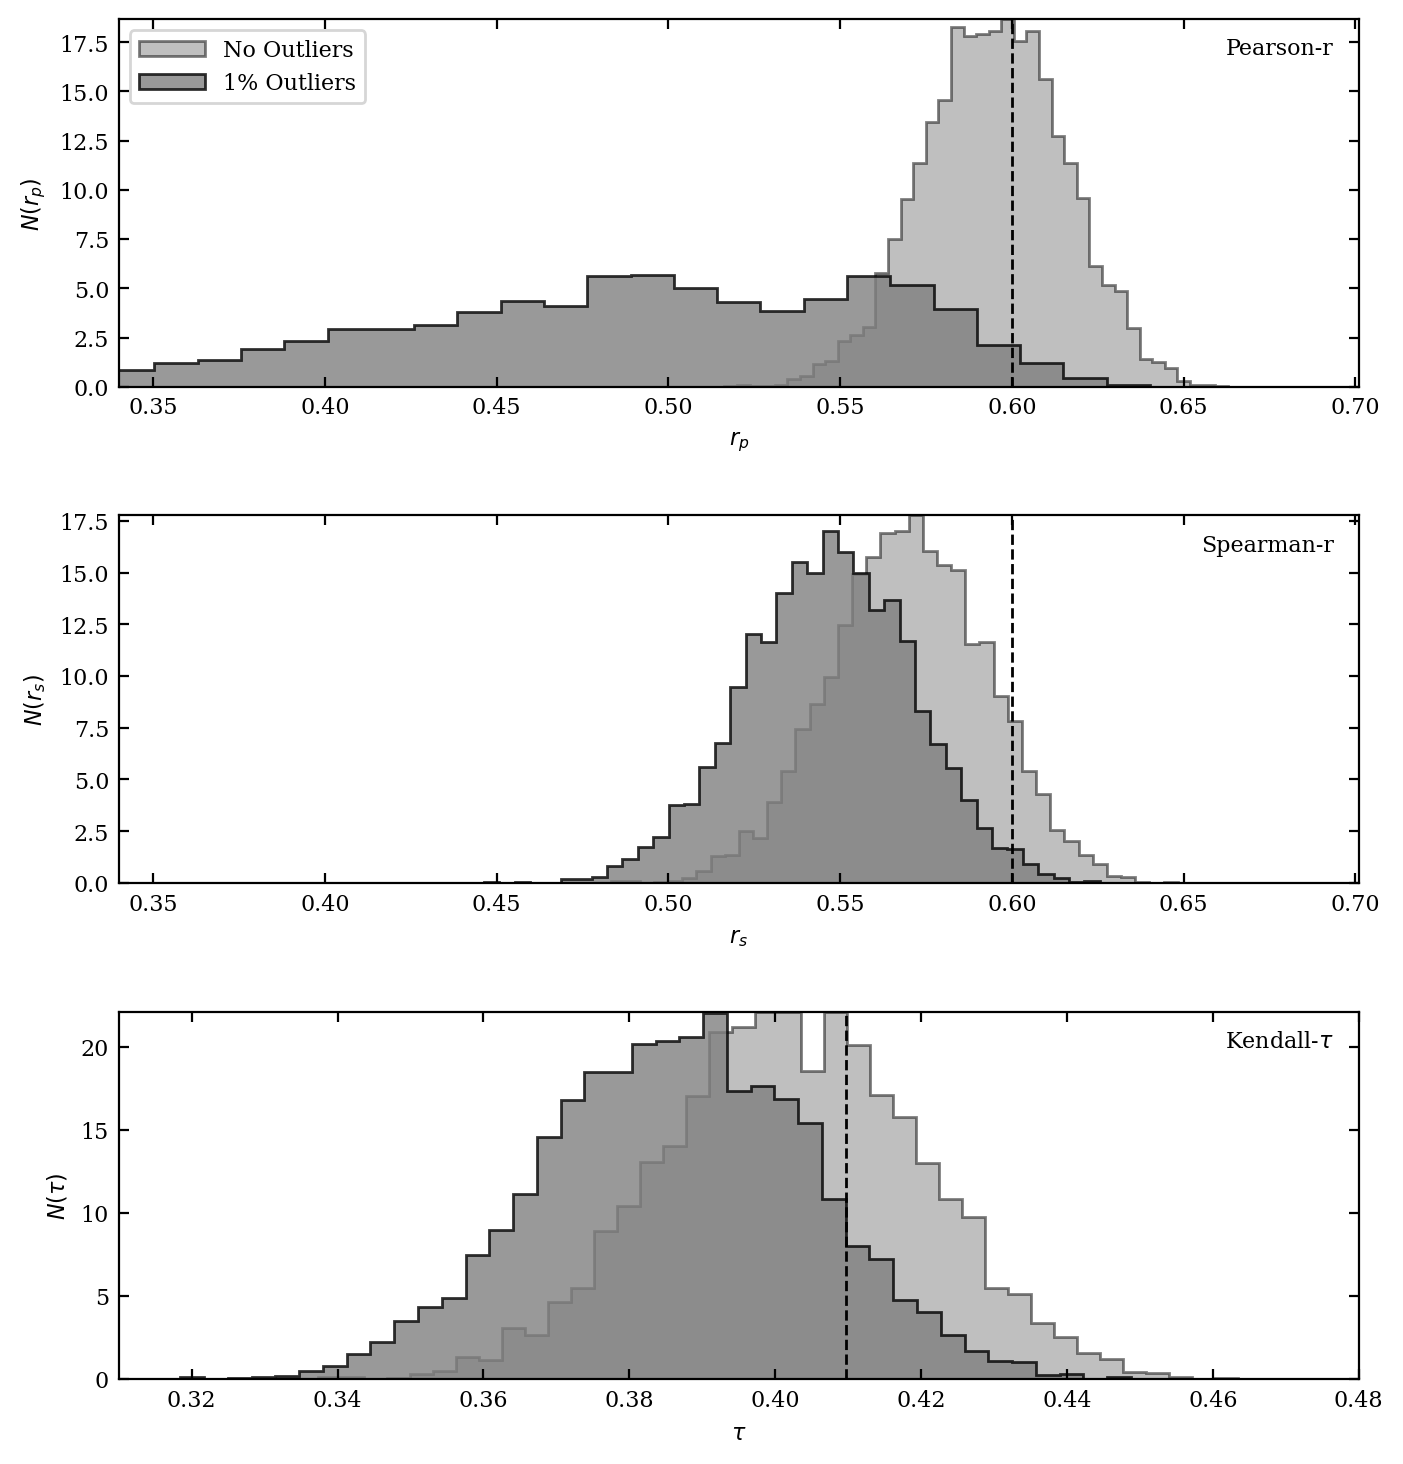

In [17]:
"""
Correlation estimates
---------------------
Figure 3.24.
Bootstrap estimates of the distribution of Pearson's, Spearman's, and Kendall's
correlation coefficients based on 2000 resamplings of the 1000 points shown
in figure 3.23. The true values are shown by the dashed lines. It is clear
that Pearson's correlation coefficient is not robust to contamination.
"""
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt

from astroML.stats.random import bivariate_normal
from astroML.utils.decorators import pickle_results

# percent sign must be escaped if usetex=True
import matplotlib
if matplotlib.rcParams.get('text.usetex'):
    pct = '\%'
else:
    pct = '%'

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

#------------------------------------------------------------
# Set parameters for the distributions
Nbootstraps = 5000
N = 1000

sigma1 = 2.0
sigma2 = 1.0
mu = (10.0, 10.0)
alpha_deg = 45.0
alpha = alpha_deg * np.pi / 180
f = 0.01

#------------------------------------------------------------
# sample the distribution
# without outliers and with outliers
np.random.seed(0)
X = bivariate_normal(mu, sigma1, sigma2, alpha, N)

X_out = X.copy()
X_out[:int(f * N)] = bivariate_normal(mu, 2, 5,
                                      45 * np.pi / 180., int(f * N))

# true values of rho (pearson/spearman r) and tau
# tau value comes from Eq. 41 of arXiv:1011.2009
rho_true = 0.6
tau_true = 2 / np.pi * np.arcsin(rho_true)


#------------------------------------------------------------
# Create a function to compute the statistics.  Since this
#  takes a while, we'll use the "pickle_results" decorator
#  to save the results of the computation to disk
@pickle_results('fig_correlations_dump.pkl')
def compute_results(N, Nbootstraps):
    results = np.zeros((3, 2, Nbootstraps))

    for k in range(Nbootstraps):
        ind = np.random.randint(N, size=N)
        for j, data in enumerate([X, X_out]):
            x = data[ind, 0]
            y = data[ind, 1]
            for i, statistic in enumerate([stats.pearsonr,
                                           stats.spearmanr,
                                           stats.kendalltau]):
                results[i, j, k] = statistic(x, y)[0]

    return results

results = compute_results(N, Nbootstraps)

#------------------------------------------------------------
# Plot the results in a three-panel plot
fig = plt.figure(figsize=(8, 8))
fig.subplots_adjust(bottom=0.1, top=0.95, hspace=0.35)

histargs = (dict(alpha=0.5, label='No Outliers'),
            dict(alpha=0.8, label='%i%s Outliers' % (int(f * 100), pct)))

distributions = ['Pearson-r', 'Spearman-r', r'Kendall-$\tau$']
xlabels = ['r_p', 'r_s', r'\tau']\

for i in range(3):
    ax = fig.add_subplot(311 + i)
    for j in range(2):
        ax.hist(results[i, j], 40, histtype='stepfilled', fc='gray',
                density=True, **histargs[j])

    if i == 0:
        ax.legend(loc=2)

    ylim = ax.get_ylim()
    if i < 2:
        ax.plot([rho_true, rho_true], ylim, '--k', lw=1)
        ax.set_xlim(0.34, 0.701)
    else:
        ax.plot([tau_true, tau_true], ylim, '--k', lw=1)
        ax.set_xlim(0.31, 0.48)
    ax.set_ylim(ylim)

    ax.text(0.98, 0.95, distributions[i], ha='right', va='top',
            transform=ax.transAxes)

    ax.set_xlabel('$%s$' % xlabels[i])
    ax.set_ylabel('$N(%s)$' % xlabels[i])

plt.show()

Let's pause for a second to see the power of checkpointing in computing! Try running the cell again and again.

Also see how Spearman's test provides a biases estimator.

**Hang on!** If you look at the code, I'm computing a distribution of estimators out of a single dataset. How on Earth is that possible?! It's called "bootstrap" and it's a very powerful tecnique. We'll see it in a bit.

# Sampling from arbitrary distributions 

Numerical simulations of the measurment process are often the only practical way to assess the complicated influences of selection effects, biases, and other processing stages of data taking. Such approaches are often called **Monte Carlo simulations**, producing **Monte Carlo or mock samples**. It is often highly beneficial to resample from arbitrary distributions in order to simulate further measurements.

Imagine you've got an arbitrary distribution $h(x)$ in analytic or histogram form (or alternatively just samples from it). How do you make more samples if it's not one of the standard distributions in `numpy` or `scipy`? We'll discuss the 1D case here in two ways. **Rejection sampling** (less preferred) and **Inverse transform sampling** (highly preferred and easy). But in high dimensions rejection sampling might be the only way forward.

Also, rejection sampling is somewhat easier to implement and could be a good choice for quick-and-dirty explorations. 



## Rejection sampling

The process for sampling from an arbitrary distribution with rejection is:

1) Decide on a straightforward *proposal distribution* $q(x)$ to propose new samples. It should be wide enough to capture the tails of $h(x)$. We'll use a uniform distribution here.

2) Generate a random sample from $q(x)$, $x_i$.

3) Now generate a random sample, $u$, from a uniform distribution in the range $[0,\mathrm{max}(h(x))]$, where the upper bound should be as large or larger than the maximum density of $h(x)$. (This could be worked out analytically or by histograming the data.)

4) If $u\leq h(x_i)$ accept the point, or else reject it and try again from step 2.


This is shown pictorally here (image reproduced by [Robert Collins class CSE586 "Computer Vision II" at PSU](http://www.cse.psu.edu/~rtc12/CSE586/))

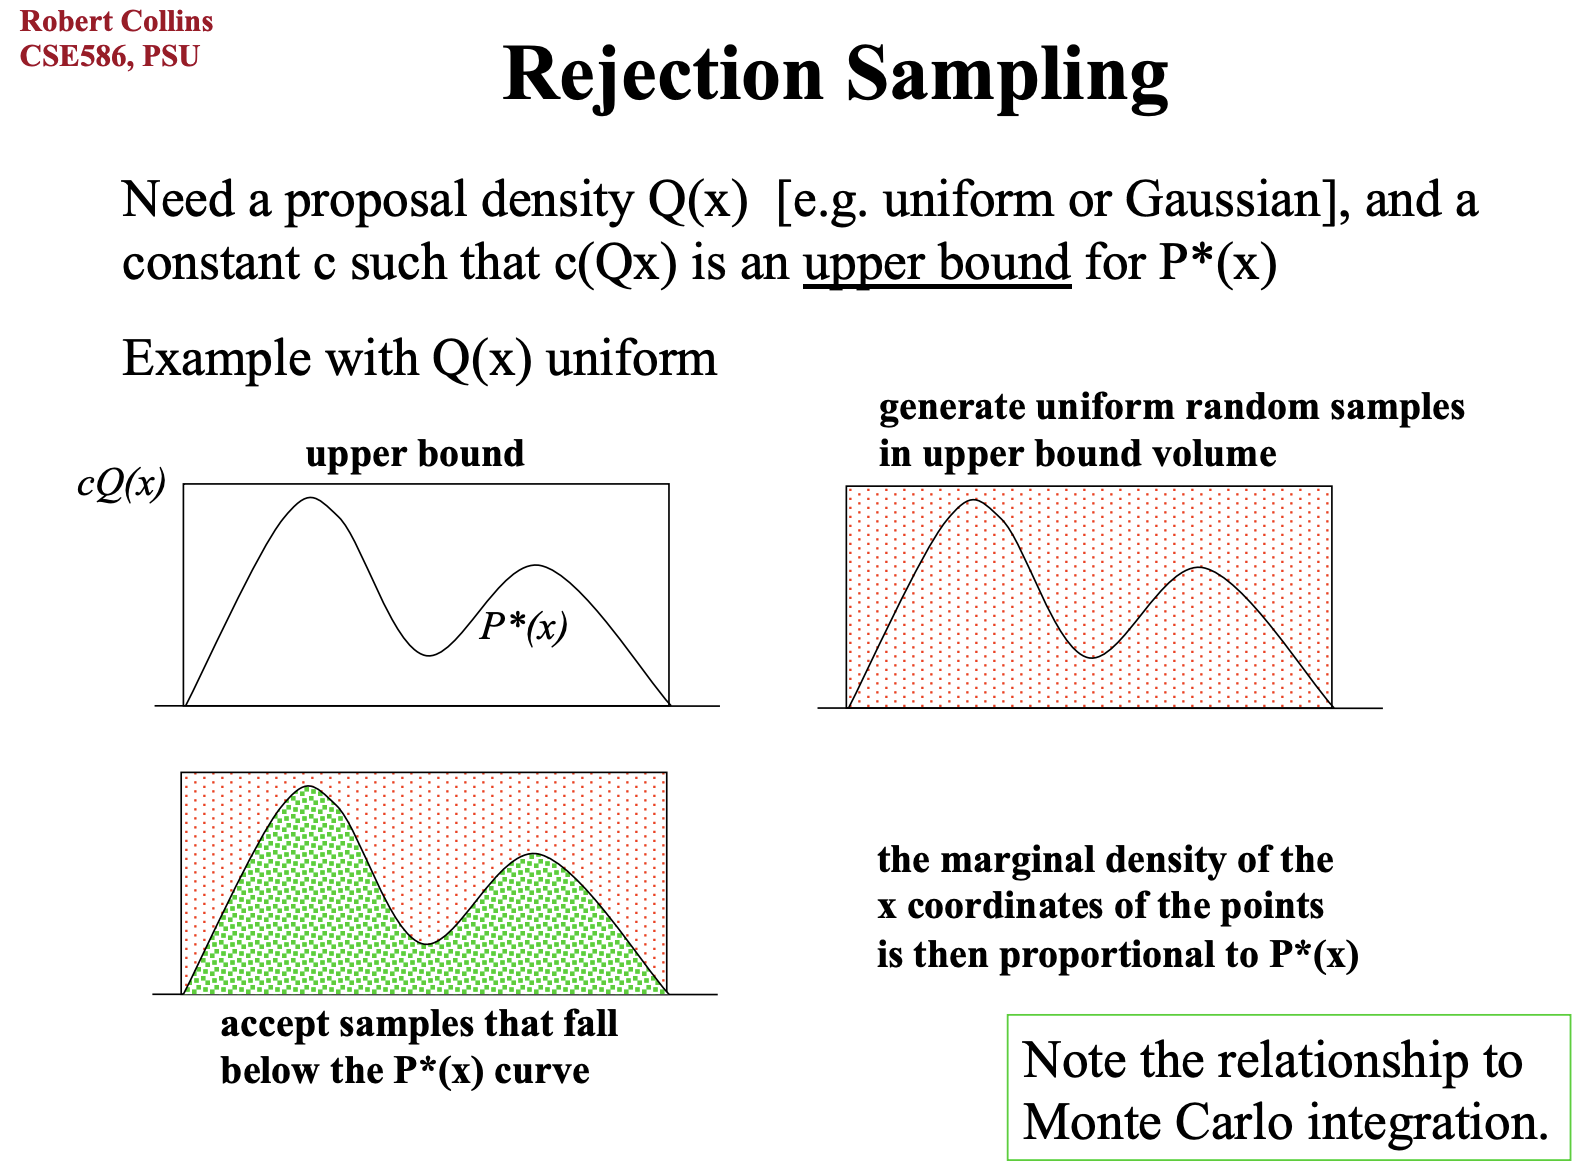

Let's try this for a simple case. Sample from $$p(x)\propto x+sin(x)$$ between 0 and 10

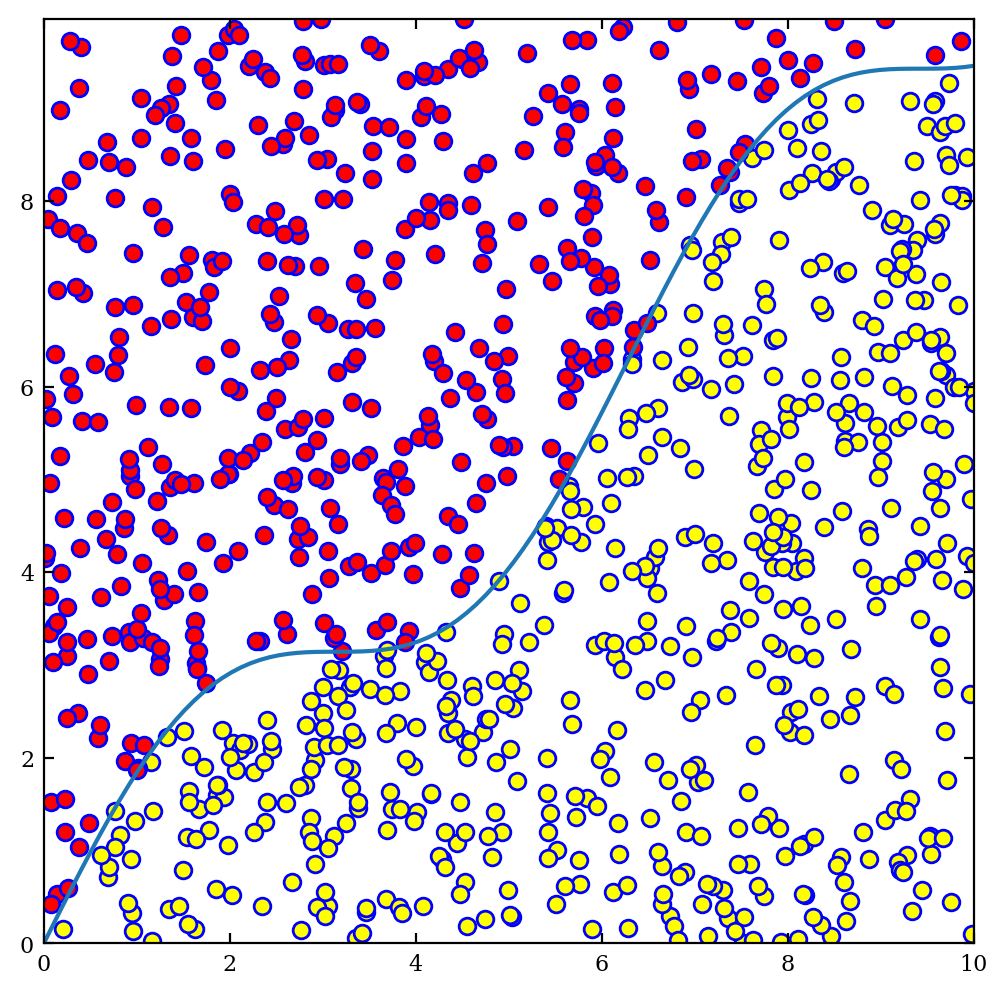

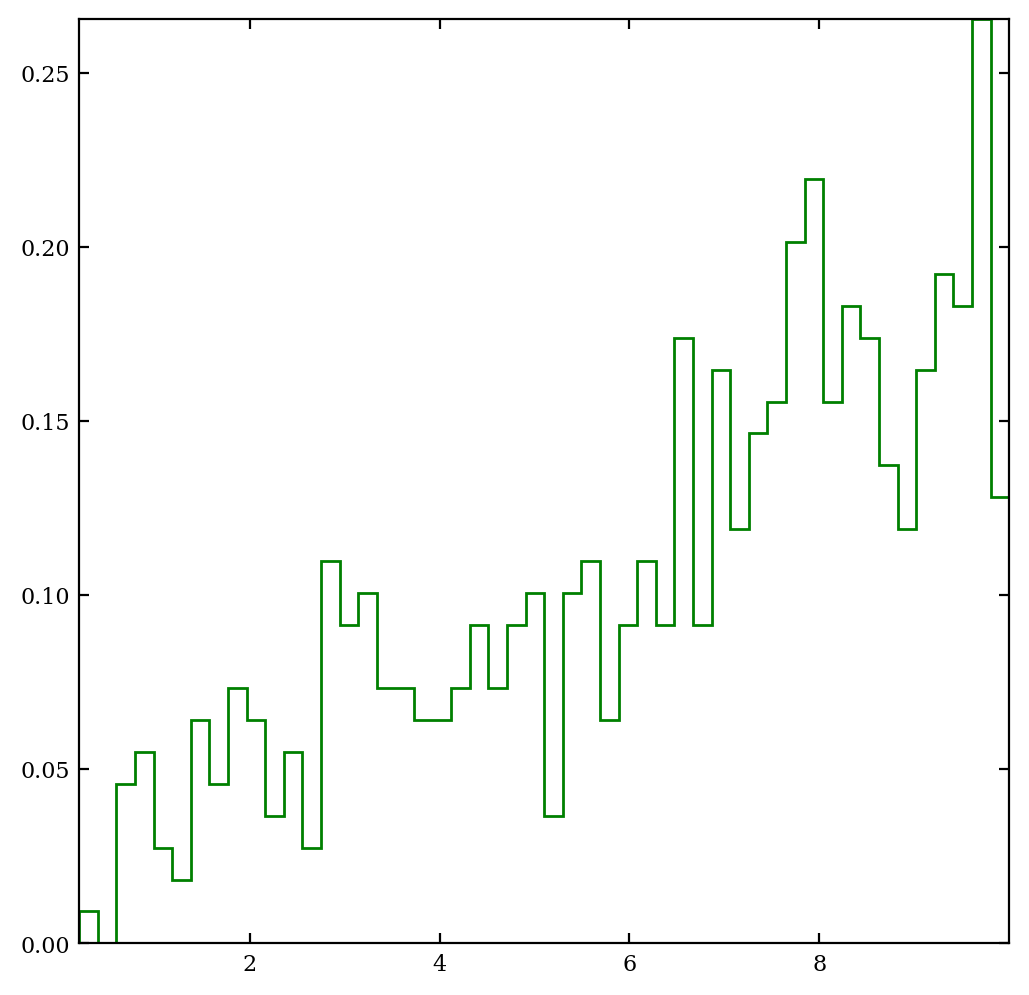

In [18]:
f = lambda x: x+np.sin(x)  # pause and look at how great lambda functions are! 

N=1000

xg = np.linspace(0,10,100)

plt.plot(xg,f(xg))


ymax = 10
x = np.random.uniform(0,10,N)
y = np.random.uniform(0,ymax,N)


plt.scatter(x[y<f(x)],y[y<f(x)],c='yellow')
plt.scatter(x[y>f(x)],y[y>f(x)],c='red')

plt.show()
goodpoints = x[y<f(x)]


plt.hist(goodpoints,bins=50,density=True,histtype='step',color='green');


## Inverse transform sampling

Rejection sampling works, but wouldn't it be awesome if we didn't have to discard *any* points during our sampling? This is the power and simplicity of **inverse transform sampling**. The process is exceedingly simple. 

1) To sample from an arbitrary $h(x)$, you will also need the cdf $H(x)$ and its inverse, the quantile function $H^{-1}(x)$. If $h(x)$ is difficult to integrate, or $H(x)$ is difficult to invert to get the quantile function, then you could use numerical techniques to interpolate or produce lookup tables.

2) Generate a random sample $u$ from a uniform random distribution $[0,1]$. 

3) Using the quantile function $H^{-1}(x)$, find the value of $x$ below which a fraction $u$ of the distribution is contained. 

4) The $x$ value you get is a random sample from $h(x)$. Easy, right?


Let's try this for a simple case. Sample from $$p(x)\propto x$$ between 0 and 10

First, the normalization is important here. 

$$p(x)= \frac{1}{50} x$$

such that $\int p(x) dx=1$ over its domain. 

The cdf is 

First I need to compute the cdf

$$ P(x)= \int_0^x  \frac{1}{50} x' dx' = \frac{x^2}{100} $$

I can now invert this

$$x = \sqrt{100 P}$$

Now it's super easy...

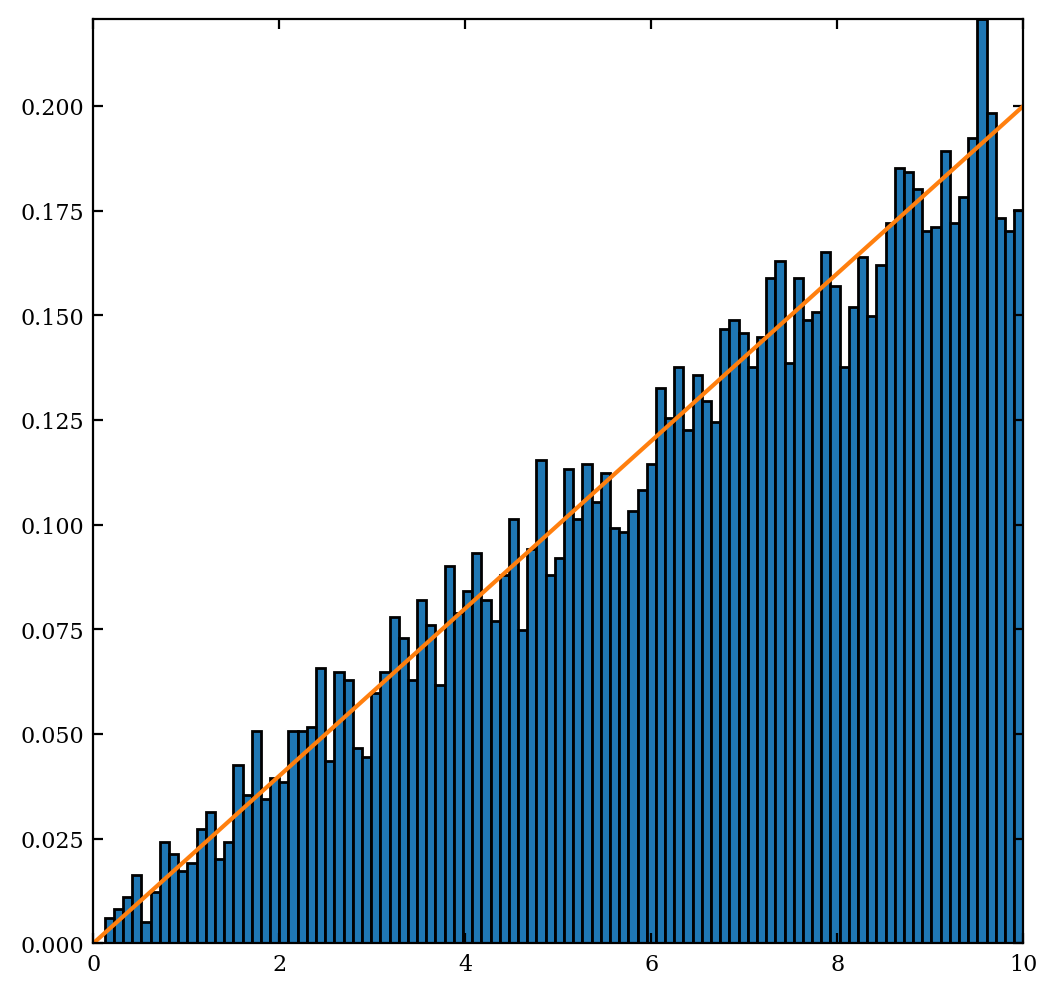

In [19]:
eps = np.random.uniform(0,1,10000)

x = (100*eps)**0.5

plt.hist(x, density=True, bins=100);

xv=np.linspace(0,10,100)
plt.plot(xv, xv/50);

Let's go back to our earlier example. Sample from $$p(x)\propto x+sin(x)$$ between 0 and 10

First I need to compute the cdf

$$ P(x) \propto \int_0^x x'+sin(x') dx' = \frac{1}{2} (2 + x^2 - 2 \cos x) $$

The normalization here is important. One must have $P(x=10)=1$. So:

$$ P(x) = \frac{2 + x^2 - 2 \cos x}{2 + 100 - 2 \cos 10} $$


At this point you need to invert the cdf and get something that looks like $x=f(P)$. In this case, our cdf cannot be inverted analytically. No worries, we'll do it numerically :-) 

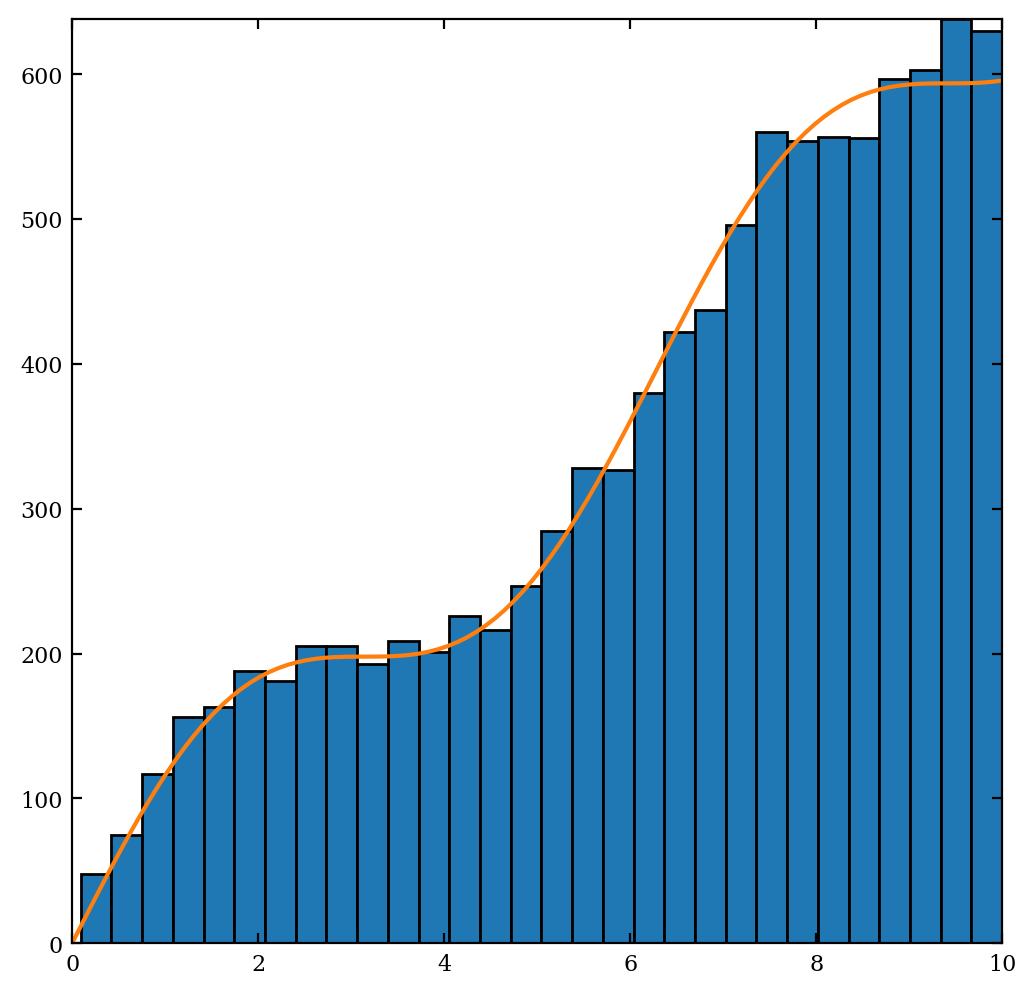

In [20]:
x=np.linspace(0,10,100)

def cdf(x):
    return (2 + x**2 - 2*np.cos(x))/(2 + 100 - 2*np.cos(10))

#plt.plot(x,cdf(x))

eps = np.random.uniform(0,1,10000)

# Using a vanilla root finder, which solves for cdf(h)=eps i.e. finds the zero of the function cdf(x)-eps
samples = [ scipy.optimize.brentq(lambda h: cdf(h)-e, 0, 10) for e in eps]

plt.hist(samples,bins=30);


xv=np.linspace(0,10,100)
plt.plot(xv, (xv+np.sin(xv)) * 63); # here I'm so lazy that I normalized it by hand... sorry!

### Cloning or upsample

In the example above we have been sampling from an known function. In most application you don't have this luxury. You're only given datapoints. This called "cloning" or "upsampling", which is: I have samples from a distribution but I'm greedy and I want more. This is crucial in modern stastical application such as bootstrap and jacknife (see next lectures).

# Cloning quasars (time to get your hands dirty). 

Let's look at the redshift distributions of the quasars in the Sloan Digital Sky Survey.

The Sloan Digital Sky Survey or SDSS is a major multi-spectral imaging and spectroscopic redshift survey using a dedicated 2.5-m wide-angle optical telescope at Apache Point Observatory in New Mexico, United States. Operations started in 1998.

In phase 1, SDSS has released photometry data 357 million (!!!) unique sources and 1.6 million spectra. In phase 2, SDSS observed the same patch of the sky many times ("time domain astronomy", and now we're going to have LSST!)

![](https://classic.sdss.org/includes/sideimages/sdss_pie2.jpg)

Download the SDSS quasar data

In [21]:
from urllib.request import urlretrieve
urlretrieve("https://das.sdss.org/va/qsocat/dr7qso.dat", './dr7qso.dat')

('./dr7qso.dat', <http.client.HTTPMessage at 0x7987eb339f20>)

In [22]:
# There are 80 header lines, skip them. The redshift is in column 3. 
#Careful that there's another z feature, but that refers to the SDSS z filter, not the redshift
z= np.loadtxt('dr7qso.dat',skiprows=80, usecols=3)

In [30]:
z

array([1.8246, 1.8373, 1.1985, ..., 1.6937, 1.2834, 1.3542],
      shape=(105783,))

Text(0.5, 0, 'z')

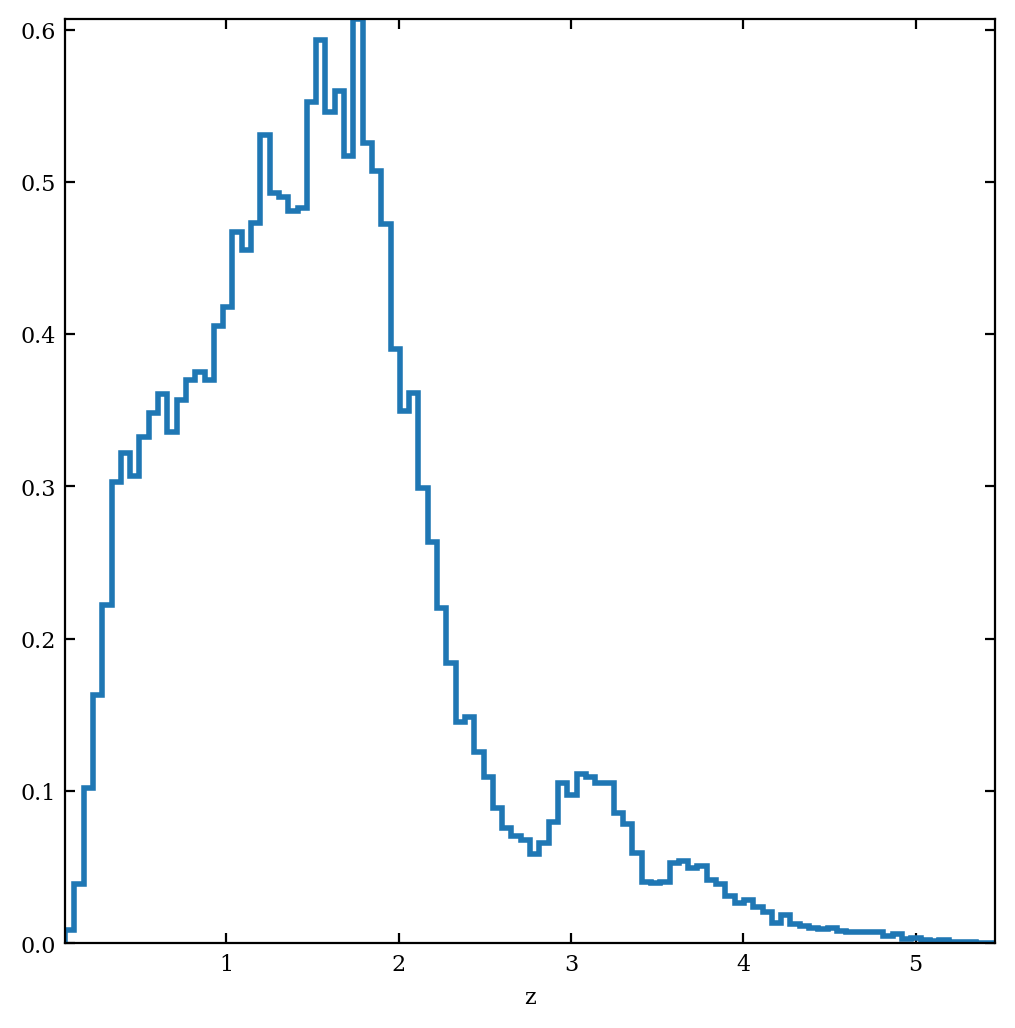

In [23]:
plt.hist(z,bins=100,density=True,histtype='step',lw=2);
plt.xlabel('z')

In [24]:
"""
from astroML.datasets import fetch_dr7_quasar

# Fetch the quasar data
data = fetch_dr7_quasar()

# select the first 10000 points
data = data[:10000]

z = data['redshift']
"""

"\nfrom astroML.datasets import fetch_dr7_quasar\n\n# Fetch the quasar data\ndata = fetch_dr7_quasar()\n\n# select the first 10000 points\ndata = data[:10000]\n\nz = data['redshift']\n"

- Upsample this distribution in hopefully two ways (but at least one of them), using both rejection sampling and inverse transform.
- Check, at least visually, that the two cloned distribitions are indeed similar to the observed one (for a quantitative check, come back to this point in a few lectures)
- Think about the cosmology of quasars. How do you think they are distributed? Overplot the theorethical distribution to the measured SDSS data. Does that agree with your expectation? 

(Hint: It shouldn't. But why?) 

The package [astropy](https://www.astropy.org/) contains a ton of useful astro things. For instance, the best-fit cosmological model from the latest Plack data is:

In [25]:
import astropy
astropy.cosmology.Planck18

FlatLambdaCDM(name='Planck18', H0=<Quantity 67.66 km / (Mpc s)>, Om0=0.30966, Tcmb0=<Quantity 2.7255 K>, Neff=3.046, m_nu=<Quantity [0.  , 0.  , 0.06] eV>, Ob0=0.04897)

[My solution](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/solutions/S04_cloningquasars.ipynb)